# ⚡ PVPC España — Modelado Multivariable con XGBoost

**Objetivo:** Incorporar variables meteorológicas al modelo de predicción
y comparar XGBoost contra el mejor modelo univariable.

**Hipótesis:** El precio eléctrico depende no solo de su historia reciente
sino de condiciones externas — temperatura (calefacción/refrigeración),
nubosidad y radiación solar (producción fotovoltaica), viento (producción eólica)
y precipitación (producción hidroeléctrica).

**Fuentes de datos:**
- Precio PVPC: API ESIOS — Red Eléctrica de España
- Meteorología: Open-Meteo (gratuita, sin token, datos horarios desde 1940)

## 0. Importaciones

In [2]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.append(str(Path.cwd().parent / "src"))

from data.fetch_weather import fetch_weather, save_weather_json, WEATHER_VARIABLES
from data.process_data import (
    load_weather_json,
    merge_price_weather,
    build_features,
    save_multivariate_dataset,
    DATA_PROCESSED_DIR,
    DATA_RAW_DIR,
)
from models.train_models import (
    load_processed_data,      # ← viene de train_models, no de process_data
    load_multivariate_data,
    split_multivariate,
    fit_xgboost,
    get_feature_importance,
    compute_metrics,
    FEATURE_COLS,
    TARGET_COL,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.titleweight": "bold", "axes.labelsize": 11})

OUTPUT_DIR = Path("../data/processed")
print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Descarga de datos meteorológicos

Open-Meteo es gratuita y no requiere token. Descargamos el mismo período
que tenemos de datos PVPC para poder fusionarlos hora a hora.

In [3]:
# Cargamos primero el CSV de precios para saber el rango de fechas
serie_pvpc = load_processed_data()

start_date = serie_pvpc.index.min().strftime("%Y-%m-%d")
end_date   = serie_pvpc.index.max().strftime("%Y-%m-%d")
print(f"Rango de fechas del PVPC: {start_date} → {end_date}")

# Descarga meteorológica (puede tardar ~10 segundos)
weather_raw = fetch_weather(start_date, end_date)
weather_filename = f"weather_{start_date}_{end_date}.json"
save_weather_json(weather_raw, weather_filename)

print(f"\n✅ Datos meteorológicos descargados y guardados")

2026-03-01 00:12:01 [INFO] Cargando datos procesados: pvpc_clean_2025-08-01_2026-02-28.csv
2026-03-01 00:12:01 [INFO] Serie cargada: 5088 registros | 2025-08-01 00:00:00+00:00 → 2026-02-28 23:00:00+00:00
2026-03-01 00:12:01 [INFO] Solicitando datos meteorológicos 2025-08-01 → 2026-02-28...


Rango de fechas del PVPC: 2025-08-01 → 2026-02-28


2026-03-01 00:12:02 [INFO] Respuesta recibida: 5088 horas de datos meteorológicos
2026-03-01 00:12:02 [INFO] JSON meteorológico guardado en: C:\Users\bryan\Documents\pvpc-forecast\data\raw\weather_2025-08-01_2026-02-28.json



✅ Datos meteorológicos descargados y guardados


## 2. Fusión precio + meteorología

In [4]:
# Cargar y fusionar
df_weather  = load_weather_json(DATA_RAW_DIR / weather_filename)

# Reconstruir el DataFrame de precio limpio (con columna geo_name)
csv_files = sorted(DATA_PROCESSED_DIR.glob("pvpc_clean_*.csv"), key=lambda f: f.stat().st_mtime)
df_price  = pd.read_csv(csv_files[-1], index_col="datetime_utc", parse_dates=True)
df_price.index = pd.to_datetime(df_price.index, utc=True)

df_merged = merge_price_weather(df_price, df_weather)

print("\nPrimeras filas del dataset combinado:")
df_merged.head(3)

2026-03-01 00:12:17 [INFO] Cargando datos meteorológicos: weather_2025-08-01_2026-02-28.json
2026-03-01 00:12:17 [INFO] Datos meteorológicos cargados: 5088 horas × 5 variables
2026-03-01 00:12:17 [INFO] Dataset combinado: 5088 horas × 6 variables (2025-08-01 → 2026-02-28)



Primeras filas del dataset combinado:


,precio_eur_mwh,temperature_2m,cloudcover,shortwave_radiation,windspeed_10m,precipitation
datetime_utc,,,,,,
2025-08-01 00:00:00+00:00,124.43,26.4,26,0.0,17.7,0.0
2025-08-01 01:00:00+00:00,112.27,25.5,91,0.0,14.3,0.0
2025-08-01 02:00:00+00:00,103.58,24.5,74,0.0,13.0,0.0


## 3. Exploración de la relación precio-meteorología

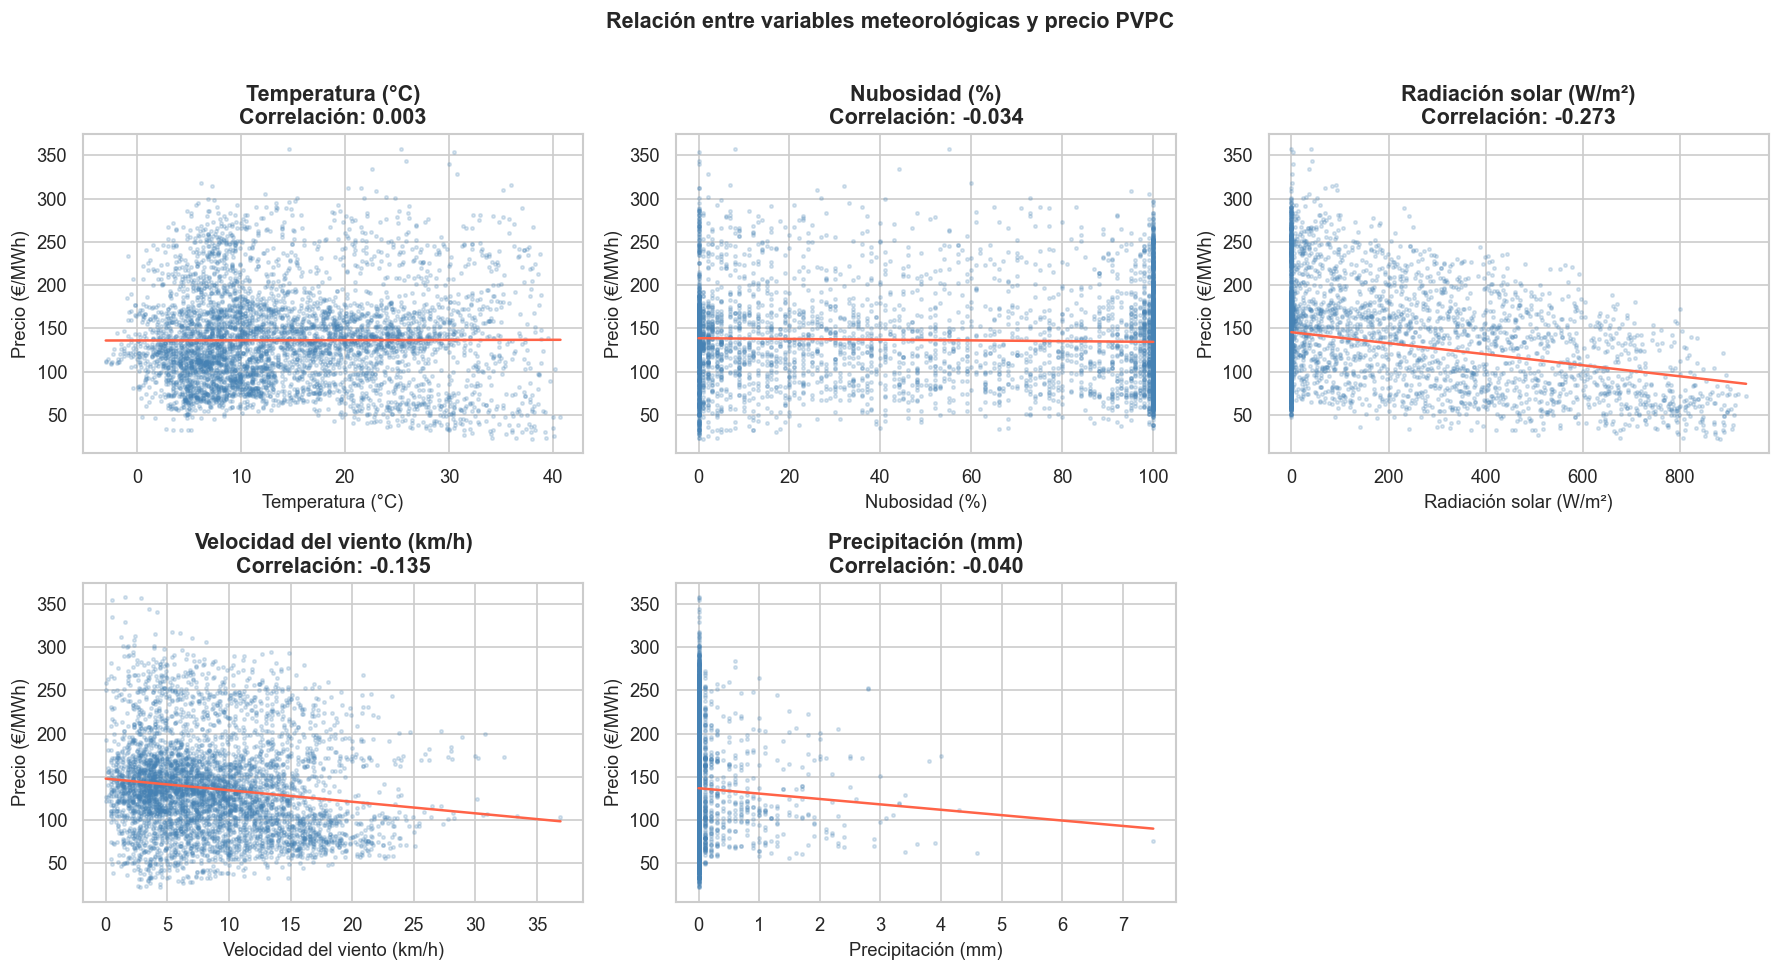

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

variables_plot = [
    ("temperature_2m",      "Temperatura (°C)"),
    ("cloudcover",          "Nubosidad (%)"),
    ("shortwave_radiation", "Radiación solar (W/m²)"),
    ("windspeed_10m",       "Velocidad del viento (km/h)"),
    ("precipitation",       "Precipitación (mm)"),
]

for ax, (var, label) in zip(axes, variables_plot):
    ax.scatter(
        df_merged[var], df_merged["precio_eur_mwh"],
        alpha=0.2, s=4, color="steelblue",
    )
    # Línea de tendencia
    z = np.polyfit(df_merged[var].dropna(), df_merged.loc[df_merged[var].notna(), "precio_eur_mwh"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df_merged[var].min(), df_merged[var].max(), 100)
    ax.plot(x_range, p(x_range), color="tomato", linewidth=1.5, label="Tendencia")

    corr = df_merged[[var, "precio_eur_mwh"]].corr().iloc[0, 1]
    ax.set_title(f"{label}\nCorrelación: {corr:.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Precio (€/MWh)")

axes[-1].axis("off")  # última celda vacía

plt.suptitle("Relación entre variables meteorológicas y precio PVPC",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "14_correlacion_meteorologia.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Construcción de features y guardado del dataset

In [6]:
df_features = build_features(df_merged)

print(f"Dataset final: {df_features.shape[0]} filas × {df_features.shape[1]} columnas")
print(f"\nFeatures disponibles:")
for col in df_features.columns:
    print(f"  {col}")

# Guardar
filename_multi = f"pvpc_multivariate_{start_date}_{end_date}.csv"
save_multivariate_dataset(df_features, filename_multi)
print(f"\n✅ Dataset guardado → data/processed/{filename_multi}")

2026-03-01 00:13:12 [INFO] Features construidas. Filas eliminadas por lags: 168 | Quedan: 4920
2026-03-01 00:13:12 [INFO] Dataset multivariable guardado en: C:\Users\bryan\Documents\pvpc-forecast\data\processed\pvpc_multivariate_2025-08-01_2026-02-28.csv


Dataset final: 4920 filas × 14 columnas

Features disponibles:
  precio_eur_mwh
  temperature_2m
  cloudcover
  shortwave_radiation
  windspeed_10m
  precipitation
  hora
  dia_semana
  mes
  es_fin_de_semana
  precio_lag_24h
  precio_lag_48h
  precio_lag_168h
  precio_media_24h

✅ Dataset guardado → data/processed/pvpc_multivariate_2025-08-01_2026-02-28.csv


## 5. División train / val / test

In [7]:
df_multi        = load_multivariate_data()
train, val, test = split_multivariate(df_multi)

print(f"Train: {len(train)} registros | {train.index.min().date()} → {train.index.max().date()}")
print(f"Val:   {len(val)}   registros | {val.index.min().date()} → {val.index.max().date()}")
print(f"Test:  {len(test)}  registros | {test.index.min().date()} → {test.index.max().date()}")

2026-03-01 00:13:36 [INFO] Cargando dataset multivariable: pvpc_multivariate_2025-08-01_2026-02-28.csv
2026-03-01 00:13:36 [INFO] Train: 3444 | Val: 738 | Test: 738


Train: 3444 registros | 2025-08-08 → 2025-12-29
Val:   738   registros | 2025-12-29 → 2026-01-29
Test:  738  registros | 2026-01-29 → 2026-02-28


## 6. Entrenamiento XGBoost

In [8]:
modelo_xgb, pred_val_xgb = fit_xgboost(train, val)
metricas_xgb = compute_metrics(val[TARGET_COL], pred_val_xgb, "XGBoost")

print(f"\nXGBoost — MAE: {metricas_xgb['MAE']} | RMSE: {metricas_xgb['RMSE']} | MAPE: {metricas_xgb['MAPE']}%")
print(f"Referencia Prophet — MAE: 33.17 | RMSE: 41.22 | MAPE: 27.94%")

2026-03-01 00:14:00 [INFO] Entrenando XGBoost...
2026-03-01 00:14:00 [INFO] XGBoost ajustado — árboles usados: 165 (early stopping)
2026-03-01 00:14:00 [INFO] [XGBoost] MAE=20.12 | RMSE=27.01 | MAPE=18.81%



XGBoost — MAE: 20.12 | RMSE: 27.01 | MAPE: 18.81%
Referencia Prophet — MAE: 33.17 | RMSE: 41.22 | MAPE: 27.94%


## 7. Importancia de las variables

2026-03-01 00:14:34 [INFO] Top features por importancia:
2026-03-01 00:14:34 [INFO]   precio_lag_168h                0.4985
2026-03-01 00:14:34 [INFO]   precio_lag_24h                 0.1185
2026-03-01 00:14:34 [INFO]   dia_semana                     0.0916
2026-03-01 00:14:34 [INFO]   shortwave_radiation            0.0681
2026-03-01 00:14:34 [INFO]   hora                           0.0466
2026-03-01 00:14:34 [INFO]   precio_media_24h               0.0374
2026-03-01 00:14:34 [INFO]   es_fin_de_semana               0.0293
2026-03-01 00:14:34 [INFO]   windspeed_10m                  0.0233
2026-03-01 00:14:34 [INFO]   mes                            0.0213
2026-03-01 00:14:34 [INFO]   precio_lag_48h                 0.0187
2026-03-01 00:14:34 [INFO]   temperature_2m                 0.0161
2026-03-01 00:14:34 [INFO]   cloudcover                     0.0156
2026-03-01 00:14:34 [INFO]   precipitation                  0.0149


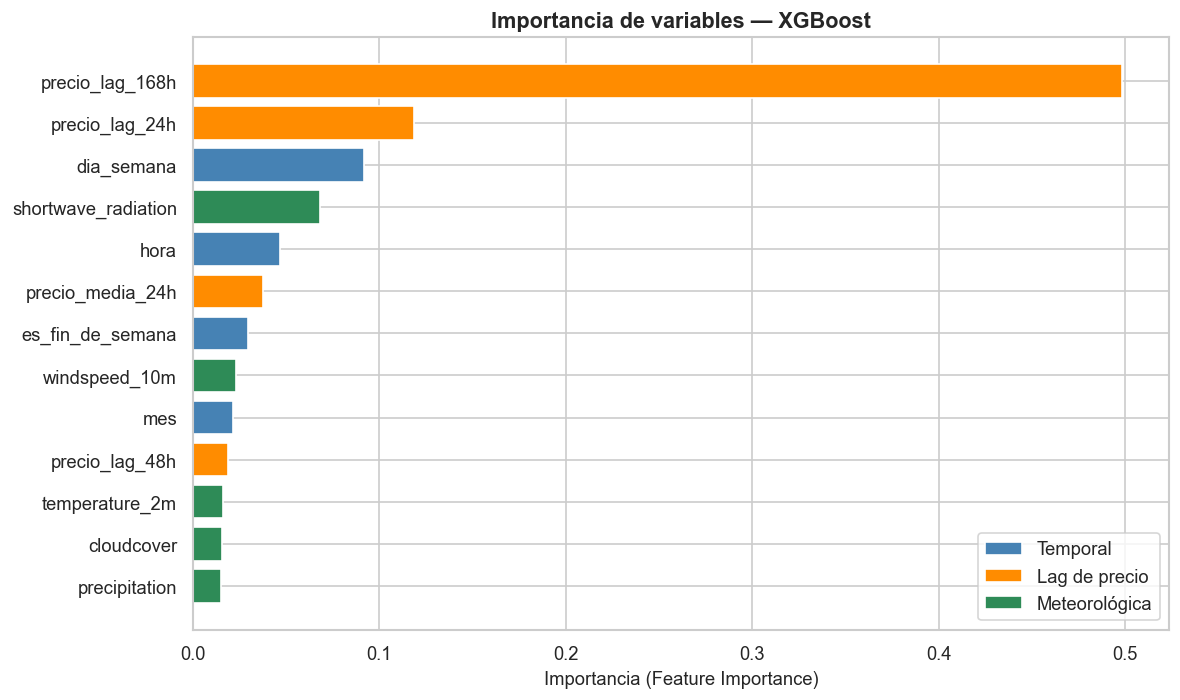

In [9]:
importancias = get_feature_importance(modelo_xgb, top_n=len(FEATURE_COLS))

fig, ax = plt.subplots(figsize=(10, 6))

# Colores por categoría de feature
def color_feature(feat):
    if feat in ["hora", "dia_semana", "mes", "es_fin_de_semana"]:
        return "steelblue"
    elif "lag" in feat or "media" in feat:
        return "darkorange"
    else:
        return "seagreen"

colores = [color_feature(f) for f in importancias.index]
bars    = ax.barh(importancias.index[::-1], importancias.values[::-1],
                  color=colores[::-1], edgecolor="white")

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="steelblue",  label="Temporal"),
    Patch(facecolor="darkorange", label="Lag de precio"),
    Patch(facecolor="seagreen",   label="Meteorológica"),
]
ax.legend(handles=leyenda, loc="lower right")

ax.set_title("Importancia de variables — XGBoost")
ax.set_xlabel("Importancia (Feature Importance)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "15_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Predicciones vs real en validación

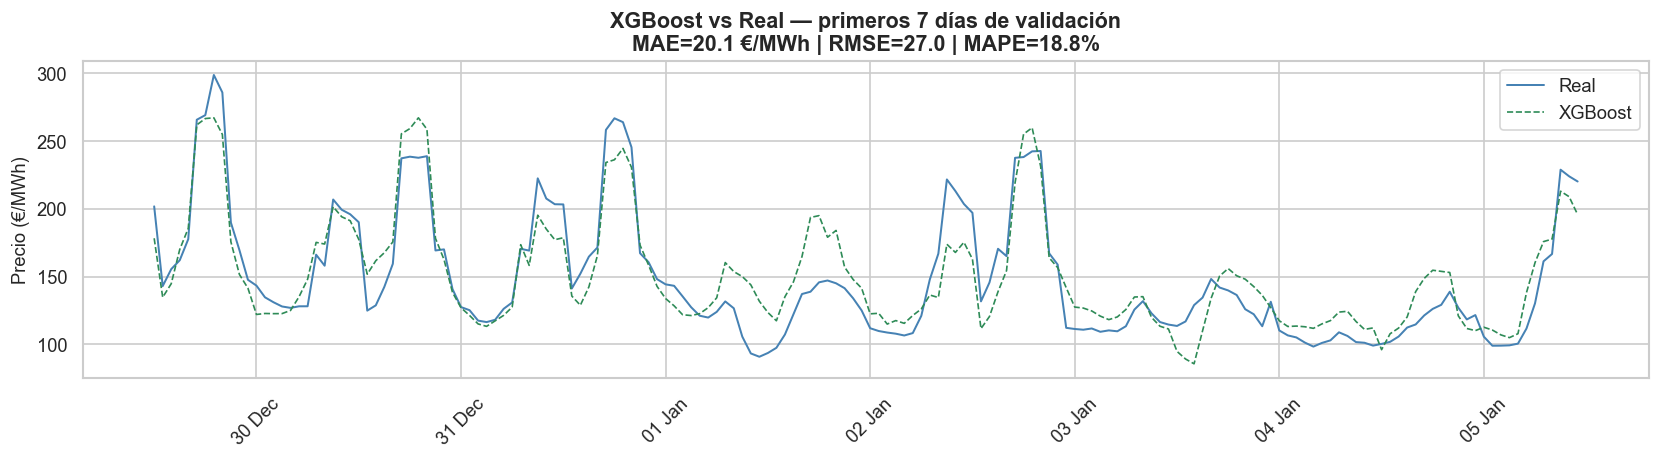

In [10]:
ventana = 24 * 7  # primera semana de validación

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val[TARGET_COL].iloc[:ventana].index,
        val[TARGET_COL].iloc[:ventana],
        color="steelblue", linewidth=1.2, label="Real")
ax.plot(pred_val_xgb.iloc[:ventana].index,
        pred_val_xgb.iloc[:ventana],
        color="seagreen", linewidth=1.0, linestyle="--", label="XGBoost")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=45)

ax.set_title(
    f"XGBoost vs Real — primeros 7 días de validación\n"
    f"MAE={metricas_xgb['MAE']:.1f} €/MWh | RMSE={metricas_xgb['RMSE']:.1f} | MAPE={metricas_xgb['MAPE']:.1f}%"
)
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "16_xgboost_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Comparativa final: XGBoost vs Prophet vs Naive

COMPARATIVA COMPLETA DE MODELOS (ordenada por MAE)
                         ranking    MAE   RMSE   MAPE
modelo                                               
XGBoost (multivariable)        1  20.12  27.01  18.81
Prophet                        2  33.17  41.22  27.94
Naive Seasonal                 3  36.07  50.75  32.95
SARIMA(1,1,1)(1,1,1,24)        4  60.25  74.60  59.17


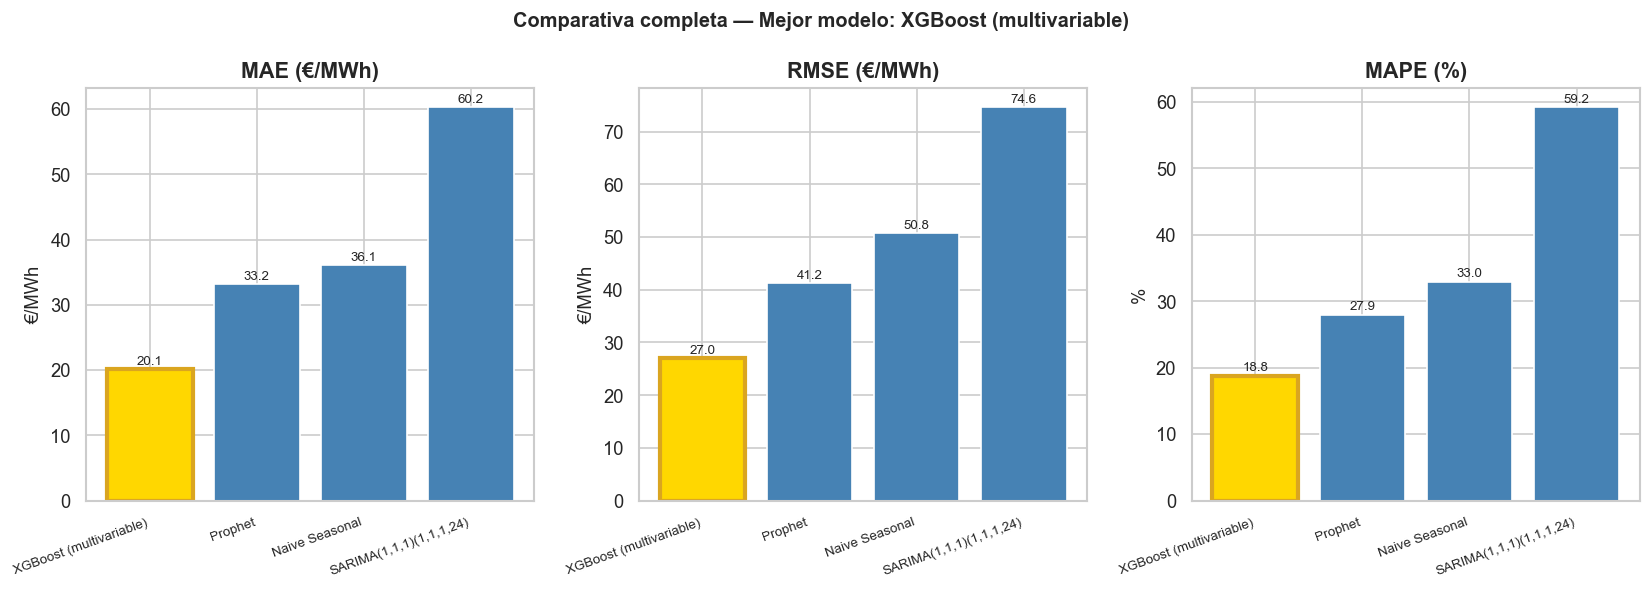

In [11]:
# Resultados del notebook anterior (Prophet ganó en validación)
resultados_anteriores = [
    {"modelo": "Naive Seasonal",            "MAE": 36.07, "RMSE": 50.75, "MAPE": 32.95},
    {"modelo": "SARIMA(1,1,1)(1,1,1,24)",   "MAE": 60.25, "RMSE": 74.60, "MAPE": 59.17},
    {"modelo": "Prophet",                   "MAE": 33.17, "RMSE": 41.22, "MAPE": 27.94},
    {"modelo": "XGBoost (multivariable)",   "MAE": metricas_xgb["MAE"],
                                            "RMSE": metricas_xgb["RMSE"],
                                            "MAPE": metricas_xgb["MAPE"]},
]

tabla = pd.DataFrame(resultados_anteriores).set_index("modelo").sort_values("MAE")
tabla.insert(0, "ranking", range(1, len(tabla) + 1))

print("COMPARATIVA COMPLETA DE MODELOS (ordenada por MAE)")
print(tabla.to_string())

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colores = ["gold" if i == 0 else "steelblue" for i in range(len(tabla))]

for ax, metrica in zip(axes, ["MAE", "RMSE", "MAPE"]):
    bars = ax.bar(tabla.index, tabla[metrica], color=colores, edgecolor="white")
    bars[0].set_edgecolor("goldenrod")
    bars[0].set_linewidth(2.5)

    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=8)

    unidad = "%" if metrica == "MAPE" else "€/MWh"
    ax.set_title(f"{metrica} ({unidad})")
    ax.set_ylabel(unidad)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)

mejor = tabla.index[0]
plt.suptitle(f"Comparativa completa — Mejor modelo: {mejor}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "17_comparativa_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Evaluación final en TEST

⚠️ Ejecutar **solo una vez** con el modelo definitivo.

2026-03-01 00:20:47 [INFO] Entrenando XGBoost...
2026-03-01 00:20:48 [INFO] XGBoost ajustado — árboles usados: 178 (early stopping)
2026-03-01 00:20:48 [INFO] [XGBoost (TEST FINAL)] MAE=18.27 | RMSE=26.54 | MAPE=15.04%



RESULTADO FINAL EN TEST — XGBoost Multivariable
  MAE  : 18.27 €/MWh
  RMSE : 26.54 €/MWh
  MAPE : 15.04%

  Referencia Prophet en test: MAE=36.15 | MAPE=38.55%


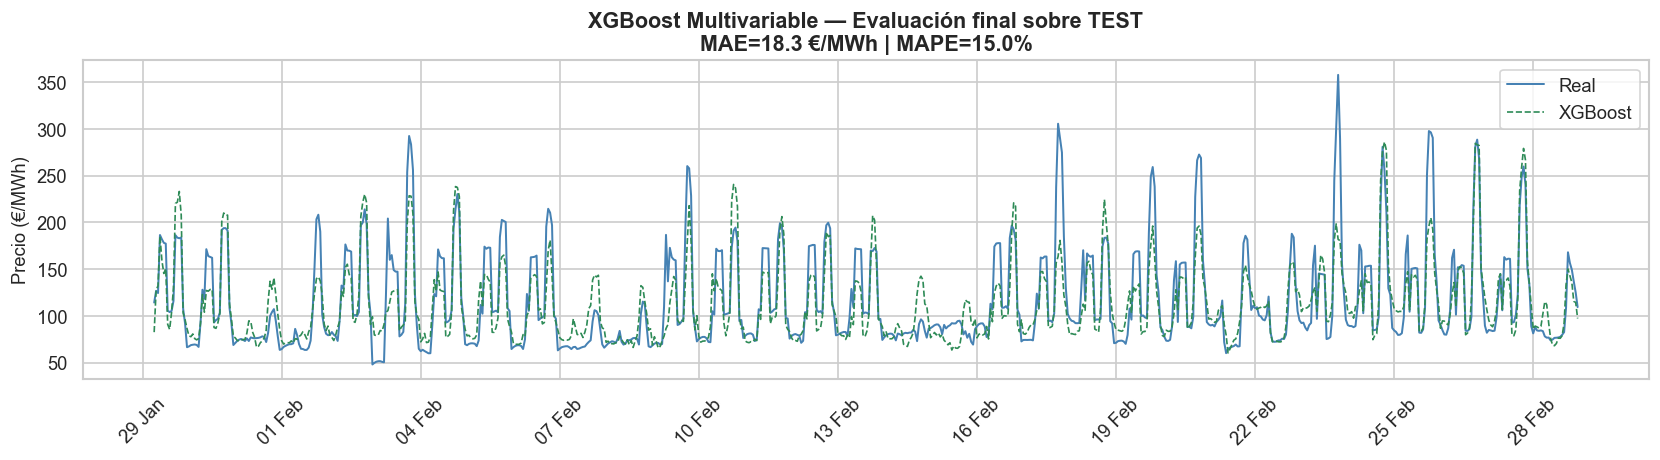

In [12]:
# Reentrenar con train+val para la evaluación final
train_full = pd.concat([train, val])
_, pred_test_xgb = fit_xgboost(train_full, test)
metricas_test = compute_metrics(test[TARGET_COL], pred_test_xgb, "XGBoost (TEST FINAL)")

print("\n" + "="*50)
print("RESULTADO FINAL EN TEST — XGBoost Multivariable")
print("="*50)
print(f"  MAE  : {metricas_test['MAE']:.2f} €/MWh")
print(f"  RMSE : {metricas_test['RMSE']:.2f} €/MWh")
print(f"  MAPE : {metricas_test['MAPE']:.2f}%")
print()
print("  Referencia Prophet en test: MAE=36.15 | MAPE=38.55%")

# Gráfico final
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test[TARGET_COL].index, test[TARGET_COL],
        color="steelblue", linewidth=1.2, label="Real")
ax.plot(pred_test_xgb.index, pred_test_xgb,
        color="seagreen", linewidth=1.0, linestyle="--", label="XGBoost")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

ax.set_title(
    f"XGBoost Multivariable — Evaluación final sobre TEST\n"
    f"MAE={metricas_test['MAE']:.1f} €/MWh | MAPE={metricas_test['MAPE']:.1f}%"
)
ax.set_ylabel("Precio (€/MWh)")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "18_xgboost_test_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Conclusiones

## 🎯 Conclusiones del Modelado Multivariante

Tras integrar variables meteorológicas y temporales, y entrenar un modelo basado en árboles de decisión (XGBoost), extraemos las siguientes conclusiones clave para el negocio:

* **Mejora drástica del rendimiento (Superando el Baseline):** El modelo XGBoost ha logrado reducir el Error Absoluto Medio (MAE) a **18.27 €/MWh** en el conjunto de test final (datos nunca vistos de febrero de 2026), logrando un margen de error (MAPE) de apenas el **15.04%**. Esto supone **cortar el error a la mitad** respecto a los modelos univariantes previos como Prophet (33.2 €/MWh) o el modelo Naive Seasonal (36.1 €/MWh).
* **La memoria del mercado (Autocorrelación):** El análisis de importancia de variables (*Feature Importance*) revela que el mercado eléctrico es altamente rutinario. Casi el 50% de la capacidad predictiva del modelo recae en el `precio_lag_168h` (el precio que hubo hace exactamente una semana a esa misma hora), seguido muy de cerca por el `precio_lag_24h` y el `dia_semana`.
* **El éxito de las Variables Exógenas (Meteorología):** La hipótesis de enriquecer el dataset con la API de Open-Meteo ha sido un éxito absoluto. La **radiación solar (`shortwave_radiation`)** se ha consolidado como la 4ª variable más importante del modelo, por encima de la hora del día. Junto con la velocidad del viento (`windspeed_10m`), el algoritmo ha interiorizado la lógica del mercado marginalista: a mayor penetración de renovables (sol y viento), menor es el precio del PVPC.
* **Viabilidad de Producción:** Con un error medio de ~18 €, este modelo es lo suficientemente robusto y preciso para ser desplegado en producción. Es capaz de anticipar con fiabilidad los valles y picos de precio del día siguiente, validando la utilidad de la alerta automática por correo electrónico para optimizar el consumo eléctrico diario.